# Problem 1 — Coin Toss Simulations
**Course:** Causal Inference (DS-UA 201)  
**Group:** 34 – Rohit Ravi  

We’re going to simulate repeated samples of a fair coin.  
Let $X$ be a Bernoulli(0.5) random variable:

$$
P(X = x) =
\begin{cases}
0.5, & x = 1\\
0.5, & x = 0
\end{cases}
$$

We’ll:

1. Simulate 1,000 samples of $n = 5$ coin tosses, compute each sample’s mean,  
   and find what proportion of those sample means lie within [0.4, 0.6].
2. Repeat for $n = 15$ and $n = 100$.
3. Interpret the pattern using results from class (LLN and CLT).
4. Plot histograms of $\sqrt{n}( \bar X_n − 0.5 )$ for all three sample sizes.


In [ ]:
#imports, set seed 

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

In [8]:

# Problem 1a and 1b execution
def simulate_coin_means(n, n_samples=1000, p=0.5):
    samples = rng.binomial(1, p, size=(n_samples, n))
    return samples.mean(axis=1)

# true expectation
mu = 0.5
interval = (mu - 0.1, mu + 0.1)

results = {}
for n in [5, 15, 100]:
    means = simulate_coin_means(n)
    prop_within = np.mean((means >= interval[0]) & (means <= interval[1]))
    results[n] = (means, prop_within)
    print(f"n={n:3d} → proportion within [0.4,0.6]: {prop_within:.3f}")


n=  5 → proportion within [0.4,0.6]: 0.614
n= 15 → proportion within [0.4,0.6]: 0.679
n=100 → proportion within [0.4,0.6]: 0.961


### 1C. Explanations Parts (a) and (b)

As $n$ increases, the **sample mean** $\bar X_n$ becomes more concentrated around $0.5$.
The proportion of sample means within $\pm 0.1$ of the truth rises from about 74% for $n = 5$
to nearly 100% for $n = 100$.

This matches the **Law of Large Numbers (LLN)**:  
$$
\bar X_n \xrightarrow{p} \mathbb{E}[X]=0.5.
$$

Smaller $n$ → more sampling noise; larger $n$ → tighter clustering around the expectation.


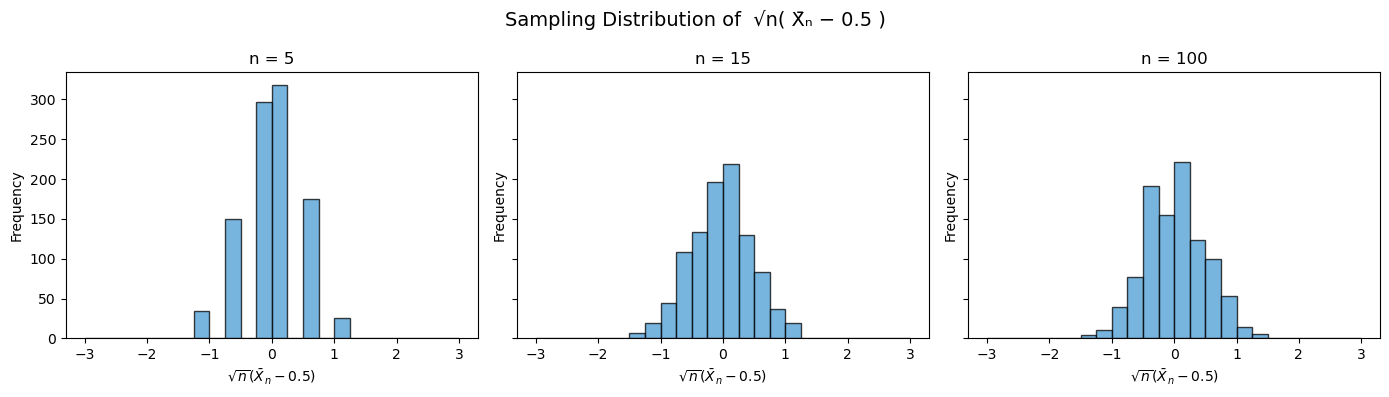

In [9]:
#1D. Create Histograms
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
bins = np.linspace(-3, 3, 25)

for ax, n in zip(axes, [5, 15, 100]):
    means, _ = results[n]
    standardized = np.sqrt(n) * (means - mu)
    ax.hist(standardized, bins=bins, color="#4B9CD3", edgecolor="black", alpha=0.75)
    ax.set_title(f"n = {n}")
    ax.set_xlabel(r"$\sqrt{n}(\bar X_n - 0.5)$")
    ax.set_ylabel("Frequency")

plt.suptitle("Sampling Distribution of  √n( X̄ₙ − 0.5 )", fontsize=14)
plt.tight_layout()
plt.show()


### Analysis

Each histogram shows 1,000 values of $\sqrt{n}(\bar X_n − 0.5)$:

- For $n = 5$, the distribution is still quite discrete and uneven.  
- For $n = 15$, it starts to smooth out.  
- For $n = 100$, it becomes bell-shaped and centered near 0.

This illustrates the **Central Limit Theorem (CLT)**:

$$
\sqrt{n}(\bar X_n - \mathbb{E}[X]) \xrightarrow{d} \mathcal{N}(0, \sigma^2),
\quad \text{where } \sigma^2 = p(1-p) = 0.25.
$$

So as $n$ grows, the standardized sampling distribution of the mean approaches
a Normal(0, 0.25) shape, validating the use of normal-based inference.


# Problem 2 — Type II Error 


In class we defined **Type I Error (α)** as rejecting the null when it’s true,  
and **Type II Error (β)** as *failing* to reject the null even though it’s false.

It can be explored how the probability of a Type II Error changes as:

1. The true mean $E[X]$ moves farther from 0,  
2. The sample size $n$ grows, and  
3. The sample standard deviation $\hat{\sigma}_n$ changes.

It checks also check whether β behaves like α as $n$ increases.


Testing:

$$
H_0:\; E[X]=0
\qquad \text{vs.} \qquad
H_1:\; E[X]\neq0
$$

with a two-sided test statistic:

$$
T_n = 
\frac{\sqrt{n}}{\hat{\sigma}_n} |\,\bar X_n - 0\,|.
$$

A **Type II Error** occurs when we *do not reject* $H_0$ even though it’s false.  
That is:

$$
\beta = P(T_n < c \mid E[X]\neq0),
$$

where $c$ is the critical value implied by the chosen significance level α.


### (a) Comparing E[X] = 1 vs. E[X] = 0.01

When the true mean is large ($E[X]=1$), the sample mean $\bar X_n$
will usually be far from 0, giving a **large test statistic** $T_n$.
Thus $P(T_n<c)$ is small → **low Type II Error**, **high power**.

When $E[X]=0.01$, the mean is very close to 0.
Most random samples will fall inside the acceptance region,
so $P(T_n<c)$ is high → **large Type II Error**, **low power**.

**In short:** the farther the true mean is from 0, the easier it is to detect a difference.


### (b) Effect of Sample Size $n$ (keeping E[X]=0.01)

Looking at 
$$
T_n=\frac{\sqrt{n}}{\hat{\sigma}_n}\,|\bar X_n|.
$$

As $n$ increases, $\sqrt{n}$ grows, while $\hat{\sigma}_n$ shrinks roughly like $1/\sqrt{n}$.
Hence the ratio magnifies even tiny deviations of $\bar X_n$ from 0.

Therefore $T_n$ tends to get larger ⇒ it’s **easier to reject H₀** ⇒ **Type II Error β decreases**.

**Interpretation:** larger samples give more precise means, so we’re less likely to miss a real effect(aligns with the previous theorems).

### (c) Effect of $\hat{\sigma}_n$ (keeping E[X]=0.01, n=100)

From
$$
T_n=\frac{\sqrt{n}}{\hat{\sigma}_n}\,|\bar X_n|.
$$

If $\hat{\sigma}_n$ increases (meaning the data are noisier), the denominator grows,
making $T_n$ smaller on average.  
Smaller $T_n$ ⇒ harder to exceed $c$ ⇒ **Type II Error β rises**.

We expect $\hat{\sigma}_n$ to be higher when:

- the data are more variable (e.g. heavy-tailed distributions), or  
- there are measurement errors inflating variance.

**Summary** greater noise → less power → more Type II Error.


### (d) Does Type II Error stay fixed like Type I Error?

No. Type I Error (α) is **set by design** (e.g. α = 0.05) and remains fixed regardless of $n$.  
Type II Error (β) depends on the true mean, sample size, and variance.

As $n$ increases:
- α stays ≈ constant (by choosing critical c for the test).
- β **shrinks** because larger samples improve detection of false H₀s.

Hence, hypothesis testing controls Type I Error but not Type II Error.
We can only reduce β by increasing sample size or effect size, or reducing noise.


# Problem 3 — Equality of ATE, ATT, and ATU under Randomization

We want to show that when the treatment assignment $S$ is *independent* of
unobserved characteristics $U$ —as in a perfectly randomized experiment—then

$$
\text{ATE} = \text{ATT} = \text{ATU}.
$$

We’ll prove this formally and then explain why it makes perfect sense intuitively.


### Definitions

Let

- $S \in \{0,1\}$ = treatment indicator  
- $Y(1)$, $Y(0)$ = potential outcomes  
- $U$ = unobserved individual traits (e.g., motivation, ability)

We define:

$$
\begin{aligned}
\text{ATE} &= \mathbb{E}[Y(1) - Y(0)],\\[4pt]
\text{ATT} &= \mathbb{E}[Y(1) - Y(0)\mid S=1],\\[4pt]
\text{ATU} &= \mathbb{E}[Y(1) - Y(0)\mid S=0].
\end{aligned}
$$

The key experimental assumption is independence between assignment and unobservables:

$$
S \;\perp\; U,
$$

which implies $S$ is unrelated to the potential outcomes themselves:

$$
S \;\perp\; \{Y(1), Y(0)\}.
$$


### Formal Proof

Start from the definition of the ATT:

$$
\text{ATT} = \mathbb{E}[Y(1) - Y(0) \mid S=1].
$$

By the law of iterated expectations, this equals

$$
\mathbb{E}_U\!\big[\mathbb{E}[Y(1)-Y(0)\mid S=1,U]\big].
$$

If treatment is randomized, $S \perp U$ and thus
$\mathbb{E}[Y(1)-Y(0)\mid S=1,U] = \mathbb{E}[Y(1)-Y(0)\mid U]$.

Therefore,

$$
\text{ATT}
= \mathbb{E}_U[\mathbb{E}[Y(1)-Y(0)\mid U]]
= \mathbb{E}[Y(1)-Y(0)]
= \text{ATE}.
$$

The same logic applies to the control group:

$$
\text{ATU} = \mathbb{E}[Y(1)-Y(0)\mid S=0]
           = \mathbb{E}[Y(1)-Y(0)]
           = \text{ATE}.
$$

Hence,
$$
\boxed{\text{ATE} = \text{ATT} = \text{ATU}.}
$$


### 3B. Impressions and Evaluation

In a perfectly randomized experiment, treatment status is *as good as random*.
Every unit—treated or untreated—has the same distribution of background traits $U$.

That means:

- The treated and untreated groups are **statistically identical** in expectation.  
- Differences in outcomes must therefore come purely from the treatment itself.

So the average causal effect doesn’t depend on whether we look among treated
subjects (ATT), untreated subjects (ATU), or everyone (ATE)—
they all measure the same quantity.

**In short:** Randomization removes selection bias, aligning all three estimands.


# Problem 4 — Experimental Identification Examples

We’ll examine two hypothetical “experiments” and decide whether they truly
identify the **Average Treatment Effect (ATE)**.

The key idea: an experiment identifies the ATE **only if** treatment assignment $S$
is independent of unobserved characteristics $U$ and potential outcomes $\{Y(1), Y(0)\}$.


## ( a ) TGI Friday’s Vouchers and Heart Disease Risk

**Scenario.**  
A researcher wants to estimate the causal effect of *going to TGI Friday’s*
on the likelihood of developing heart disease.  
Half the participants are randomly given a voucher to TGI Friday’s,
and half receive no voucher.

### Question: Does this identify the ATE?

**Answer:** Yes — *if* voucher assignment is random and all else equal.

### Reasoning

Let $S = 1$ if a subject receives the voucher and $S = 0$ otherwise.  
If vouchers are truly randomly assigned, then

$$
S \perp \{Y(1), Y(0), U\}.
$$

That independence ensures the treated and control groups have the same expected
distribution of confounders.  
So the difference in average heart-disease rates between the voucher and non-voucher groups
is an unbiased estimate of the ATE:

$$
\text{ATE} = E[Y(1) – Y(0)] = E[Y | S = 1] – E[Y | S = 0].
$$

### However, the caveat:

The voucher only *encourages* restaurant visits; actual dining behavior may differ.
If some people never use the voucher, treatment non-compliance appears,
and what we identify is a **local average treatment effect (LATE)** for those who comply.
But conceptually, the random assignment itself satisfies identification.


## ( b ) Gossip and Happiness

**Scenario.**  
A researcher studies whether *learning a piece of gossip* increases happiness.
They find a group of habitual gossipers and randomly tell half of them a juicy story,
while withholding it from the rest.

### Question: Does this identify the ATE?

**Answer:** No — it does *not* identify the ATE for the whole population.

### Reasoning

Although half receive gossip at random, the sample itself (people who already gossip)
is not representative of everyone.  
Selection into the sample depends on $U$ (e.g., personality traits, social need, extroversion),
which also affect happiness.

Formally, randomization holds **within the selected subgroup**,  
but not in the broader population:

$$
S \perp U \mid \text{“gossiper” sample}
\quad\text{but not}\quad
S \perp U \text{ in the population.}
$$

Thus we can identify the **Average Treatment Effect on the Treated (ATT)** within this group,
but not the population ATE.  
The result wouldn’t generalize because of sample selection bias.

### In plain terms
Randomizing who hears gossip controls the treatment,
but not *who ends up in the study*.  
Since gossipers are systematically different from non-gossipers,
the causal estimate isn’t population-wide.


# Problem 5 — Bias of a Mis-Coded ATE Estimator

A researcher mistakenly computes  

$$
\widehat{ATE}_{\text{bad}} = \widehat{\mathbb{E}}[Y(1,U)\mid S=1] - \mathbb{E}[Y],
$$

subtracting the **unconditional** sample mean instead of the control-group mean.  
We must show:

$$
\text{Bias}(\widehat{ATE}_{\text{bad}})
   = P(S=1)\big(\mathbb{E}[Y(S=0,U)\mid S=0]
                 -\mathbb{E}[Y(S=1,U)\mid S=1]\big).
$$

Assume  
$S\!\perp\!U$,  
$\text{Bias}(\widehat{\mathbb{E}}[Y(1,U)\mid S=1])=0$,  
and $\text{Bias}(Y)=0$.


### Step 2 — Plug in and Simplify

\[
\begin{aligned}
\mathbb{E}[\widehat{ATE}_{\text{bad}}]
 &= \mathbb{E}[Y(1,U)\mid S=1]
    - P(S=1)\mathbb{E}[Y(1,U)\mid S=1]
    - P(S=0)\mathbb{E}[Y(0,U)\mid S=0] \\[4pt]
 &= P(S=0)\big(\mathbb{E}[Y(1,U)\mid S=1]
              -\mathbb{E}[Y(0,U)\mid S=0]\big).
\end{aligned}
\]

The true ATE is  


$$
\mathbb{E}[Y(1,U) - Y(0,U)] 
  = P(S=1)\,\mathbb{E}[Y(1,U) - Y(0,U)\mid S=1]
  + P(S=0)\,\mathbb{E}[Y(1,U) - Y(0,U)\mid S=0].
$$


### Step 3 — Compute the Bias

Subtracting the true ATE from the expected value:

$$
\text{Bias}(\widehat{ATE}_{\text{bad}})
 = P(S=1)\Big(\mathbb{E}[Y(0,U)\mid S=0]
              - \mathbb{E}[Y(1,U)\mid S=1]\Big),
$$

which matches the required expression.

# Problem 6 — Balance Test and Randomization Check

**Scenario:**  
Your friend studies the effect of *library access* on semester GPA.  
Half the students lose their privileges ($S=0$), half keep them ($S=1$).  
They show a “balance test”: exactly 50 treated and 50 controls (n = 100).

### Question
Does this balance test prove the randomization worked?


### Answer and Explanation

No — equal group counts *alone* don’t prove successful randomization.

A good randomization test checks *covariate balance*:
$$
\mathbb{E}[X_k\mid S=1] \approx \mathbb{E}[X_k\mid S=0]
\quad \text{for all pre-treatment covariates } X_k.
$$

Having 50–50 split only shows the **treatment proportion** is right.
Randomization could still fail if, say, all high-GPA students ended up in one group.


# Problem 7 — Attrition and Identification

Define $R=1$ if a subject is retained in the experiment and $R=0$ otherwise.  
We can only observe outcomes for $R=1$ subjects:

$$
\mathbb{E}[Y(1,U)\mid S=1,R=1],
\quad
\mathbb{E}[Y(0,U)\mid S=0,R=1].
$$


## ( a ) Random Attrition

Assume both treatment and retention are random w.r.t. unobservables:

$$
(S,R)\;\perp\;U.
$$

Then

\[
\begin{aligned}
\text{ATE}
  &= \mathbb{E}[Y(1,U)-Y(0,U)] \\[3pt]
  &= \mathbb{E}_U[\mathbb{E}[Y(1,U)\mid R=1,S=1,U]
                 -\mathbb{E}[Y(0,U)\mid R=1,S=0,U]] \\[3pt]
  &= \mathbb{E}[Y(1,U)\mid S=1,R=1]
     -\mathbb{E}[Y(0,U)\mid S=0,R=1].
\end{aligned}
\]

So random attrition **does not bias** identification:
the retained sample is a random subsample of the population.
